In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import LiqFunDobPen as lf
import ParametersLiq as lp
import time 
from IPython.display import clear_output

In [2]:
df = pd.read_csv("double_pendulum_dataset.csv") # Charge the csv(DATA)
# We have to turn it into an array
data = df.values
# Separate inputs and outputs
X = data[:, :4] # Inputs
Y = data[:, 4:] # Outputs

In [3]:
# Computation of the mean and std 
X_mean, X_std = lf.compute_stats(X)
Y_mean, Y_std = lf.compute_stats(Y)
# Normalization
X_norm = lf.norm(X, X_mean, X_std)
Y_norm = lf.norm(Y, Y_mean, Y_std)

In [4]:
# We need time sequences
X_seq = []
Y_seq = []
for i in range(len(X)-lp.seq_len):
    X_seq.append(X_norm[i:i+lp.seq_len])
    Y_seq.append(Y_norm[i:i+lp.seq_len])
X_seq = np.array(X_seq)
Y_seq = np.array(Y_seq)

In [5]:
net = lf.LiquidNetwork(
    input_size=X.shape[1],
    hidden_size=lp.hidden_size,
    output_size=Y.shape[1]
)

# Gradient acummulator(mean)
m_W_in = np.zeros_like(net.W_in)
m_W_rec = np.zeros_like(net.W_rec)
m_W_out = np.zeros_like(net.W_out)
m_bias = np.zeros_like(net.bias)
m_b_out = np.zeros_like(net.bias_out)
# Gradient variance
v_W_in = np.zeros_like(net.W_in)
v_W_rec = np.zeros_like(net.W_rec)
v_W_out = np.zeros_like(net.W_out)
v_bias = np.zeros_like(net.bias)
v_b_out = np.zeros_like(net.bias_out)

t_adam = 0 #Iteration counter

dt = 0.01 #Step in time integration
rollout_steps = 10 # How many steps ahead the net predicts
tbptt_steps = 20 # Length of trained memory


# TRAINING LOOP
for epoch in range(lp.epochs):

    start = time.time()
    total_loss = 0
    lr = lp.initial_lr 

    indices = np.random.permutation(len(X_seq)) #Random permutation of the inex to change the sequences order

    for i in indices[:15000]: # 15000 sequences per epoch

        E0 = lf.energy(X_seq[i, 0]) # Energy in the initial state of the sequence

        # Gradients initializer
        grad_W_in_total = np.zeros_like(net.W_in)
        grad_W_rec_total = np.zeros_like(net.W_rec)
        grad_W_out_total = np.zeros_like(net.W_out)
        grad_bias_total = np.zeros_like(net.bias)
        grad_b_out_total = np.zeros_like(net.bias_out)

        seq_len = len(X_seq[i]) # Number of temporal steps of the sequence

        loss = 0

        for t0 in range(0, seq_len - rollout_steps, tbptt_steps): # Division of each sequence into temporal blocks, we dont train each sequence at a time, division in windows 

            if t0 == 0: # Reset of the state at the begining of each sequence
                net.reset()
            # Tracking arrays for the backward
            states = []
            outputs = []
            inputs = []
            targets = []
            # Auxiliary variables for the rollout
            rollout_states = None
            rollout_inputs = None

            # FORWARD 
            for t in range(t0, min(t0 + tbptt_steps, seq_len - rollout_steps)): #Track of every t instant of the sequence; Every iteration is a physical step of the system

                x_t = X_seq[i, t] # Input
                y_t = Y_seq[i, t] # Target
                y_pred = net.step(x_t)
                
                loss += 1.1 * lf.mse_loss(y_pred, y_t) # Local term of the data loss

                #  ROLLOUT 
                if t % 8 == 0: # Condition to execute the rollout
                    rollout_states = []
                    rollout_inputs = []

                    x = x_t.copy() # Save the state because the rollout cant affect the real forward
                    saved_state = net.state.copy() # Restore the state
                    

                    for k in range(rollout_steps): # Free simulation without data

                        y_roll = net.step(x, dt) # Net prediction (alpha1, alpha 2)

                        rollout_states.append(net.state.copy())
                        rollout_inputs.append(x.copy())

                        theta = x[:2]
                        omega = x[2:]
                        alpha = y_roll
                        # Integration
                        omega_half = omega + 0.5 * dt * alpha
                        theta = theta + dt * omega_half
                        omega = omega_half + 0.5 * dt * alpha

                        x_new = np.empty_like(x)
                        x_new[:2] = theta
                        x_new[2:] = omega
                        x = x_new
                    # Comparation of prediction and real                    
                    x_real = X_seq[i, t + rollout_steps]
                    loss += 0.15 * lf.mse_loss(x, x_real) # Term of how the rollout prediction and the data are alike loss
                    E_pred = lf.energy(x)
                    E_real = lf.energy(X_seq[i, t + rollout_steps]) # Computes energy in the rollout
                    
                    loss += 0.003 * (E_pred - E0)**2 # Term of the energy diference loss
                    loss += 0.001 * np.sum(y_pred**2)# Term to avoid crazy accelerations, this loss term penalizes huge alphas
                    loss += 0.003 * np.sum(np.maximum(0, y_pred * x_t[2:]) )  # Loss term to have an opposite sing in speed and acceleration
                    loss += 0.003 * np.sum(np.maximum(0, y_pred * x_t[:2]))   # Loss term to have an opposite sing in angle and acceleration 
                    
                    


                    net.state = saved_state # Go back to the initial state in order to not change the training with the rollout

               
                states.append(net.state.copy())
                outputs.append(y_pred)
                inputs.append(x_t)
                targets.append(y_t)
                
            num_steps = len(states)
            loss /= (num_steps + 1e-6)


            #  BACKWARD 
            # Weights gradients; Loss derivative with respect to each parameter
            grad_W_in = np.zeros_like(net.W_in) # Input loss gradient
            grad_W_rec = np.zeros_like(net.W_rec) # Memory loss gradient
            grad_W_out = np.zeros_like(net.W_out) # Output loss gradient
            grad_bias = np.zeros_like(net.bias) # Offset state
            grad_b_out = np.zeros_like(net.bias_out) # Offset exit

            grad_state_next = np.zeros(net.hidden_size) # Gradient for the next time-step
            grad_state_roll = np.zeros(net.hidden_size) # Propagate gradients through the rollout

        
            #  BPTT (Learning through time)
            for t in reversed(range(len(states))): # Run time backwards
                # Rebuild the state in t
                state_t = states[t]
                input_t = inputs[t]
                y_pred = outputs[t]
                y_true = targets[t]
                # Local error
                grad_y = lf.mse_grad(y_pred, y_true)

                grad_W_out += grad_y[:, None] * state_t[None, :]
                grad_b_out += grad_y
                #Propagate error to the state (h(t) affects this state and future ones)
                grad_state = net.W_out.T @ grad_y + grad_state_next
                # Activation derivative
                z = net.W_in @ input_t + net.W_rec @ state_t + net.bias
                tanh_z = np.tanh(z)

                dtanh = 1 - tanh_z**2
                # Inner gradient
                grad = np.clip(dtanh * grad_state,-5, 5)
                # Gradient of inner weights
                grad_W_rec += grad[:, None] * state_t[None, :]
                grad_W_in += grad[:, None] * input_t[None, :]
                grad_bias += grad
                # Temporal propagation
                grad_state_next = net.W_rec.T @ grad * dt

            #  ACUMULAR GRADIENTES 
            grad_W_in_total += grad_W_in
            grad_W_rec_total += grad_W_rec
            grad_W_out_total += grad_W_out
            grad_bias_total += grad_bias
            grad_b_out_total += grad_b_out

        #  GLOBAL CLIPPING  
        total_norm = np.sqrt(
            np.sum(grad_W_in_total**2) +
            np.sum(grad_W_rec_total**2) +
            np.sum(grad_W_out_total**2) +
            np.sum(grad_bias_total**2) +
            np.sum(grad_b_out_total**2)
        )

        scale = min(1.0, 1.0 / (total_norm + 1e-6))

        grad_W_in_total *= scale
        grad_W_rec_total *= scale
        grad_W_out_total *= scale
        grad_bias_total *= scale
        grad_b_out_total *= scale

        #  ADAM update
        t_adam += 1

        

        m_W_in, v_W_in = lf.adam_update(net.W_in, grad_W_in_total, m_W_in, v_W_in, t_adam, lr)
        m_W_rec, v_W_rec = lf.adam_update(net.W_rec, grad_W_rec_total, m_W_rec, v_W_rec, t_adam, lr)
        m_W_out, v_W_out = lf.adam_update(net.W_out, grad_W_out_total, m_W_out, v_W_out, t_adam, lr)
        m_bias, v_bias = lf.adam_update(net.bias, grad_bias_total, m_bias, v_bias, t_adam, lr)
        m_b_out, v_b_out = lf.adam_update(net.bias_out, grad_b_out_total, m_b_out, v_b_out, t_adam, lr)
        total_loss += loss

    total_loss /= len(X_seq)

    end = time.time()

    print(f"Epoch {epoch}, Loss: {total_loss:.4f}, Time: {end - start:.2f}s")
    

Epoch 0, Loss: 1.2802, Time: 91.83s
Epoch 1, Loss: 1.2447, Time: 90.95s
Epoch 2, Loss: 1.2027, Time: 90.65s
Epoch 3, Loss: 1.1889, Time: 97.78s
Epoch 4, Loss: 1.1377, Time: 121.08s
Epoch 5, Loss: 1.1085, Time: 162.51s
Epoch 6, Loss: 1.0915, Time: 129.59s
Epoch 7, Loss: 1.0680, Time: 144.44s
Epoch 8, Loss: 1.0484, Time: 104.61s
Epoch 9, Loss: 1.0542, Time: 100.59s
Epoch 10, Loss: 1.0684, Time: 103.34s
Epoch 11, Loss: 1.0463, Time: 154.41s
Epoch 12, Loss: 1.0264, Time: 188.24s
Epoch 13, Loss: 1.0292, Time: 116.31s
Epoch 14, Loss: 1.0228, Time: 114.11s
Epoch 15, Loss: 1.0033, Time: 123.24s
Epoch 16, Loss: 1.0130, Time: 131.61s
Epoch 17, Loss: 1.0155, Time: 213.93s
Epoch 18, Loss: 1.0104, Time: 164.57s
Epoch 19, Loss: 1.0186, Time: 133.24s
Epoch 20, Loss: 1.0256, Time: 195.75s
Epoch 21, Loss: 1.0263, Time: 131.59s
Epoch 22, Loss: 1.0189, Time: 110.59s
Epoch 23, Loss: 1.0168, Time: 128.69s
Epoch 24, Loss: 1.0254, Time: 106.14s
Epoch 25, Loss: 1.0399, Time: 128.60s
Epoch 26, Loss: 1.0313, Ti

In [6]:
x0 = X_norm[0]
traj = lf.simulate(net, x0, steps = 300)

Text(0.5, 1.0, 'Simulación red líquida del péndulo doble')

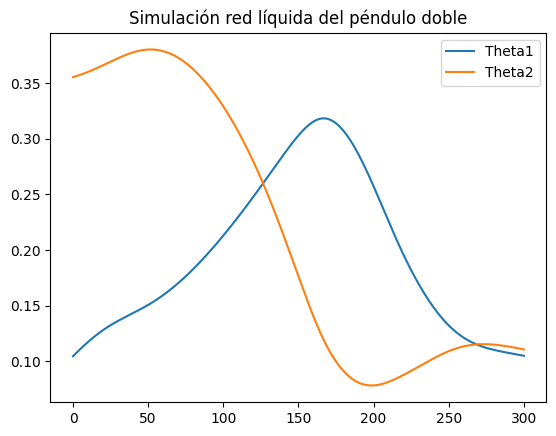

In [7]:
plt.plot(traj[:, 0], label="Theta1")
plt.plot(traj[:, 1], label="Theta2")
plt.legend()
plt.title("Simulación red líquida del péndulo doble")

In [8]:
#git